# Resiliência Estrutural da Rede Global de Rotas Aéreas

In [41]:
import warnings
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import powerlaw
import seaborn as sns
from collections import Counter
from matplotlib.ticker import MultipleLocator, LogLocator

import utils
import main as f1


plt.rcParams.update({"figure.figsize": (12, 6), "figure.dpi": 130, "savefig.bbox": "tight"})
utils.setup_directories()

### Snapshots Disponíveis

In [6]:
snapshots = utils.list_snapshots()

if not snapshots:
    print("Nenhum snapshot encontrado. O tráfego será estimado pelo fallback (contagem de companhias).")
else:
    print(f"{len(snapshots)} snapshot(s) disponível(is):\n")
    for s in snapshots:
        size_kb = s.stat().st_size / 1024
        print(f"   {s.name}  ({size_kb:.1f} KB)")

11 snapshot(s) disponível(is):

   opensky_snapshot_20260427_0152.json  (52.0 KB)
   opensky_snapshot_20260424_1808.json  (118.2 KB)
   opensky_snapshot_20260424_1552.json  (137.2 KB)
   opensky_snapshot_20260424_1147.json  (114.0 KB)
   opensky_snapshot_20260423_1715.json  (130.7 KB)
   opensky_snapshot_20260423_1511.json  (115.4 KB)
   opensky_snapshot_20260423_0124.json  (57.5 KB)
   opensky_snapshot_20260422_1946.json  (85.9 KB)
   opensky_snapshot_20260422_1338.json  (113.0 KB)
   opensky_snapshot_20260422_1302.json  (116.3 KB)
   opensky_snapshot_20260419_1808.json  (90.0 KB)


### Carregamento e Pré-processamento dos Dados

In [12]:
airports = f1.load_airports()
routes_raw = f1.load_routes()
routes = f1.filter_routes(routes_raw, airports)

print(f"Aeroportos carregados:  {len(airports):,}")
print(f"Rotas brutas:           {len(routes_raw):,}")
print(f"Rotas após filtragem:   {len(routes):,}")

airports.head()

[INFO] Carregando aeroportos de /home/victor/Documentos/UNICAMP/Rubens/data/airports.dat
[INFO] Carregando rotas de /home/victor/Documentos/UNICAMP/Rubens/data/routes.dat
Aeroportos carregados:  6,067
Rotas brutas:           67,240
Rotas após filtragem:   66,433


,AirportID,Name,IATA,ICAO,Latitude,Longitude,Country
0,1,Goroka Airport,GKA,AYGA,-6.081690,145.391998,Papua New Guinea
1,2,Madang Airport,MAG,AYMD,-5.207080,145.789001,Papua New Guinea
2,3,Mount Hagen Kagamuga Airport,HGU,AYMH,-5.826790,144.296005,Papua New Guinea
3,4,Nadzab Airport,LAE,AYNZ,-6.569803,146.725977,Papua New Guinea
4,5,Port Moresby Jacksons International Airport,POM,AYPY,-9.443380,147.220001,Papua New Guinea


In [13]:
# Enriquece com distâncias e pesos de tráfego
routes = f1.enrich_routes(routes, airports)
routes[["SrcIATA", "DstIATA", "distance_km", "traffic_estimate", "real_flight_count"]].head(10)

[INFO] Calculando distâncias geodésicas…
[INFO] Carregando snapshot mais recente: opensky_snapshot_20260427_0152.json
[INFO] Snapshot carregado: 62 pares origem-destino únicos.
[INFO] Integrando pesos do snapshot OpenSky…
[INFO] Usando fallback para estimar tráfego (contagem de rotas).
[INFO] 24 rotas enriquecidas com dados reais do OpenSky.


,SrcIATA,DstIATA,distance_km,traffic_estimate,real_flight_count
0,AER,KZN,1506.825604,1,0
1,ASF,KZN,1040.438320,1,0
2,ASF,MRV,448.164909,1,0
3,CEK,KZN,770.508500,1,0
4,CEK,OVB,1338.631467,2,0
5,DME,KZN,715.649350,4,0
6,DME,NBC,892.382788,1,0
7,DME,UUA,951.432198,1,0
8,EGO,KGD,1171.881495,1,0
9,EGO,KZN,1008.253110,1,0


In [14]:
# Cobertura do OpenSky: quantas rotas têm dados reais
total = len(routes)
com_dados_reais = (routes["real_flight_count"] > 0).sum()
print(f"Rotas com dados reais do OpenSky:  {com_dados_reais:,} / {total:,}  ({com_dados_reais/total*100:.1f}%)")
print(f"Rotas usando apenas fallback:       {total - com_dados_reais:,}")

Rotas com dados reais do OpenSky:  24 / 66,433  (0.0%)
Rotas usando apenas fallback:       66,409


### Construção do Grafo

In [42]:
G = f1.build_graph(airports, routes)
utils.export_graph(G)

[INFO] Grafo exportado para /home/victor/Documentos/UNICAMP/Rubens/output


### Análise Topológica

In [17]:
n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
largest_wcc = max(nx.weakly_connected_components(G), key=len)
avg_degree = np.mean([d for _, d in G.degree()])
density = nx.density(G)

stats = pd.DataFrame({
    "Métrica": ["Nós", "Arestas", "Grau Médio", "Densidade", "Componente Gigante", "% na C. Gigante"],
    "Valor": [
        f"{n_nodes:,}",
        f"{n_edges:,}",
        f"{avg_degree:.2f}",
        f"{density:.5f}",
        f"{len(largest_wcc):,}",
        f"{len(largest_wcc)/n_nodes*100:.1f}%"
    ]
})
stats.set_index("Métrica")

,Valor
Métrica,
Nós,"6,067"
Arestas,"36,706"
Grau Médio,12.10
Densidade,0.00100
Componente Gigante,"3,167"
% na C. Gigante,52.2%


### Componentes Conexas

In [18]:
# Componentes Fortemente Conexas (SCC)
sccs = list(nx.strongly_connected_components(G))
n_sccs = len(sccs)
scc_sizes = sorted([len(c) for c in sccs], reverse=True)

# Componentes Fracamente Conexas (WCC)
wccs = list(nx.weakly_connected_components(G))
n_wccs = len(wccs)
wcc_sizes = sorted([len(c) for c in wccs], reverse=True)

print(f"Componentes fortemente conexas (SCC): {n_sccs:,}")
print(f"Maior SCC:  {scc_sizes[0]:,} nós  ({scc_sizes[0]/n_nodes*100:.1f}% do grafo)")
print()
print(f"Componentes fracamente conexas  (WCC): {n_wccs:,}")
print(f"Maior WCC:  {wcc_sizes[0]:,} nós  ({wcc_sizes[0]/n_nodes*100:.1f}% do grafo)")

Componentes fortemente conexas (SCC): 2,923
Maior SCC:  3,126 nós  (51.5% do grafo)

Componentes fracamente conexas  (WCC): 2,882
Maior WCC:  3,167 nós  (52.2% do grafo)


### Distribuição dos Tamanhos das Componentes

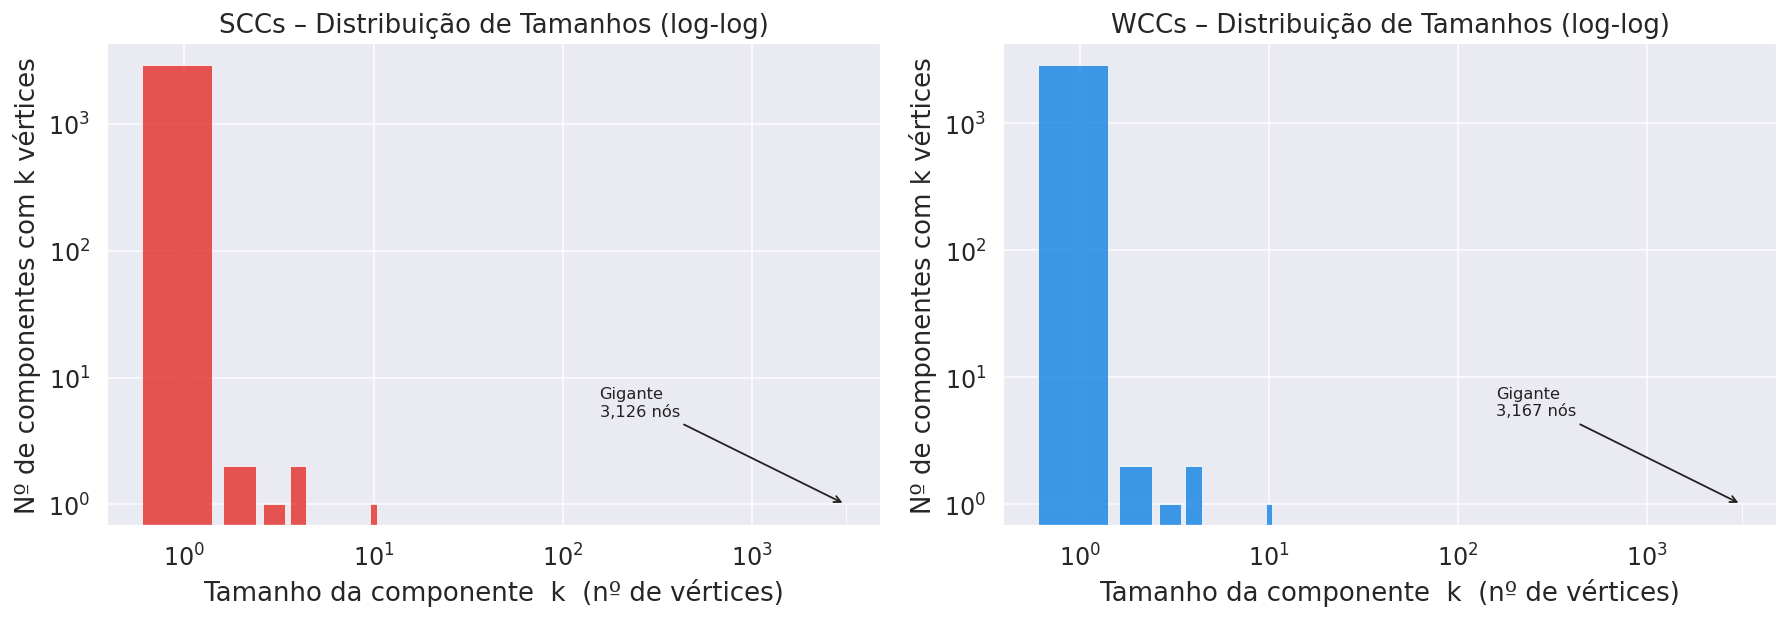

In [ ]:
def plot_component_size_dist(sizes, title, color, ax):
    counts = Counter(sizes)
    ks = sorted(counts.keys())
    freqs = [counts[k] for k in ks]

    ax.bar(
        ks, freqs,
        color=color, alpha=0.85,
        edgecolor="white", linewidth=0.5
    )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel("Tamanho da componente  k  (nº de vértices)")
    ax.set_ylabel("Nº de componentes com k vértices")
    ax.set_title(title)

    ax.xaxis.set_major_locator(LogLocator(base=10.0))
    ax.yaxis.set_major_locator(LogLocator(base=10.0))

    ax.grid(True, which="major", axis="both",
            linestyle="-", linewidth=1.1, alpha=0.7)

    giant_k = ks[-1]
    giant_n = counts[giant_k]

    ax.annotate(
        f"Gigante\n{giant_k:,} nós",
        xy=(giant_k, giant_n),
        xytext=(
            max(ks[0], giant_k * 0.05),
            giant_n * 5 if giant_n < max(freqs) else giant_n * 0.3
        ),
        fontsize=9,
        color="#222222",
        arrowprops=dict(
            arrowstyle="->",
            color="#222222",
            linewidth=1.0
        ),
    )


with sns.axes_style("dark"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    if n_sccs > 1:
        plot_component_size_dist(
            scc_sizes,
            "SCCs – Distribuição de Tamanhos (log-log)",
            "#E53935",
            axes[0]
        )
    else:
        axes[0].text(
            0.5, 0.5,
            "Apenas 1 SCC\n(grafo fortemente conexo)",
            ha="center", va="center",
            transform=axes[0].transAxes,
            fontsize=13,
            color="white"
        )
        axes[0].set_title("SCCs – Distribuição de Tamanhos")
        axes[0].axis("off")

    if n_wccs > 1:
        plot_component_size_dist(
            wcc_sizes,
            "WCCs – Distribuição de Tamanhos (log-log)",
            "#1E88E5",
            axes[1]
        )
    else:
        axes[1].text(
            0.5, 0.5,
            "Apenas 1 WCC\n(grafo fracamente conexo)",
            ha="center", va="center",
            transform=axes[1].transAxes,
            fontsize=13,
            color="white"
        )
        axes[1].set_title("WCCs – Distribuição de Tamanhos")
        axes[1].axis("off")

    plt.tight_layout()
    fig.savefig(utils.OUTPUT_DIR / "distribuicao_tamanho_componentes.png")
    plt.show()

### Distribuição de Grau (Lei de Potência)

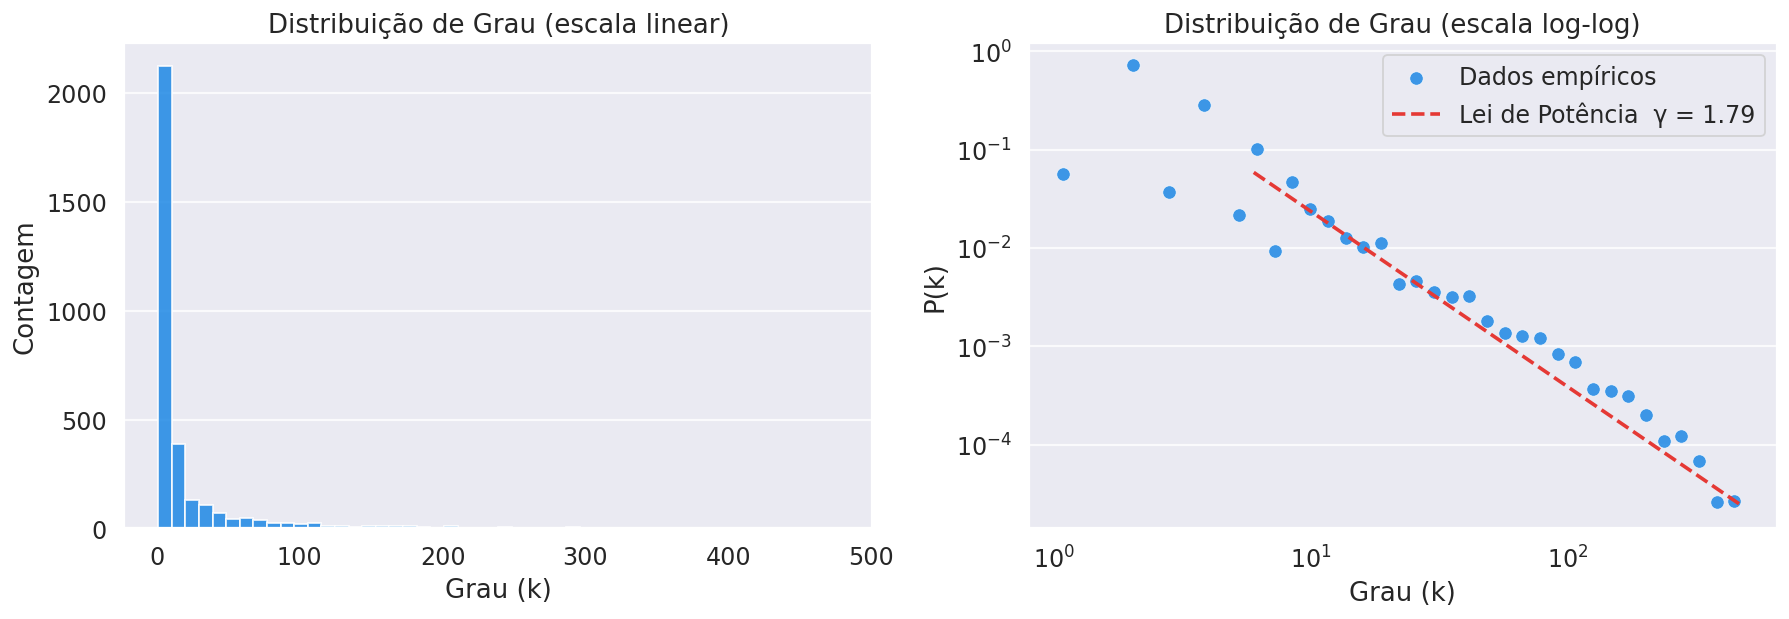


Expoente γ (lei de potência): 1.788
x_min estimado: 6.0


In [27]:
degrees = np.array([d for _, d in G.degree() if d > 0])
fit = powerlaw.Fit(degrees, discrete=True, verbose=False)

with sns.axes_style("dark"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Histograma linear ---
    axes[0].hist(
        degrees, bins=50, 
        edgecolor="white", alpha=0.85,
        color="#1E88E5"  # Material Blue 600
    )
    axes[0].set_xlabel("Grau (k)")
    axes[0].set_ylabel("Contagem")
    axes[0].set_title("Distribuição de Grau (escala linear)")

    # Ajuste de ticks (certifique-se de que MultipleLocator foi importado de matplotlib.ticker)
    axes[0].xaxis.set_major_locator(MultipleLocator(100))
    axes[0].yaxis.set_major_locator(MultipleLocator(500))
    axes[0].grid(True, axis="y", linestyle="-", linewidth=1.2, alpha=0.8)

    # --- Log-log com ajuste da lei de potência ---
    bins = np.logspace(np.log10(degrees.min()), np.log10(degrees.max()), 40)
    counts, edges = np.histogram(degrees, bins=bins, density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    mask = counts > 0

    # Pontos de dados
    axes[1].scatter(
        centers[mask], counts[mask],
        alpha=0.85, label="Dados empíricos",
        color="#1E88E5",  # Material Blue 600
        edgecolors="white", linewidths=0.4, s=55,
    )

    # Cálculo da linha de ajuste
    x_fit = np.logspace(np.log10(fit.power_law.xmin), np.log10(degrees.max()), 100)
    C = counts[mask][-1] * (centers[mask][-1] ** fit.power_law.alpha)

    # Linha da Lei de Potência
    axes[1].plot(
        x_fit, C * x_fit ** (-fit.power_law.alpha),
        linestyle="--", linewidth=2,
        color="#E53935",  # Material Red 600
        label=f"Lei de Potência  γ = {fit.power_law.alpha:.2f}",
    )

    axes[1].set_xscale("log")
    axes[1].set_yscale("log")
    axes[1].set_xlabel("Grau (k)")
    axes[1].set_ylabel("P(k)")
    axes[1].set_title("Distribuição de Grau (escala log-log)")
    axes[1].legend()

    # Ajuste de divisões log (certifique-se de que LogLocator foi importado)
    axes[1].xaxis.set_major_locator(LogLocator(base=10.0))
    axes[1].yaxis.set_major_locator(LogLocator(base=10.0))
    axes[1].grid(True, axis="y", linestyle="-", linewidth=1.2, alpha=0.8)

    # Salvamento e exibição
    plt.tight_layout()
    fig.savefig(utils.OUTPUT_DIR / "distribuicao_grau.png")
    plt.show()

print(f"\nExpoente γ (lei de potência): {fit.power_law.alpha:.3f}")
print(f"x_min estimado: {fit.power_law.xmin}")


### Top 10 Aeroportos por Grau Total

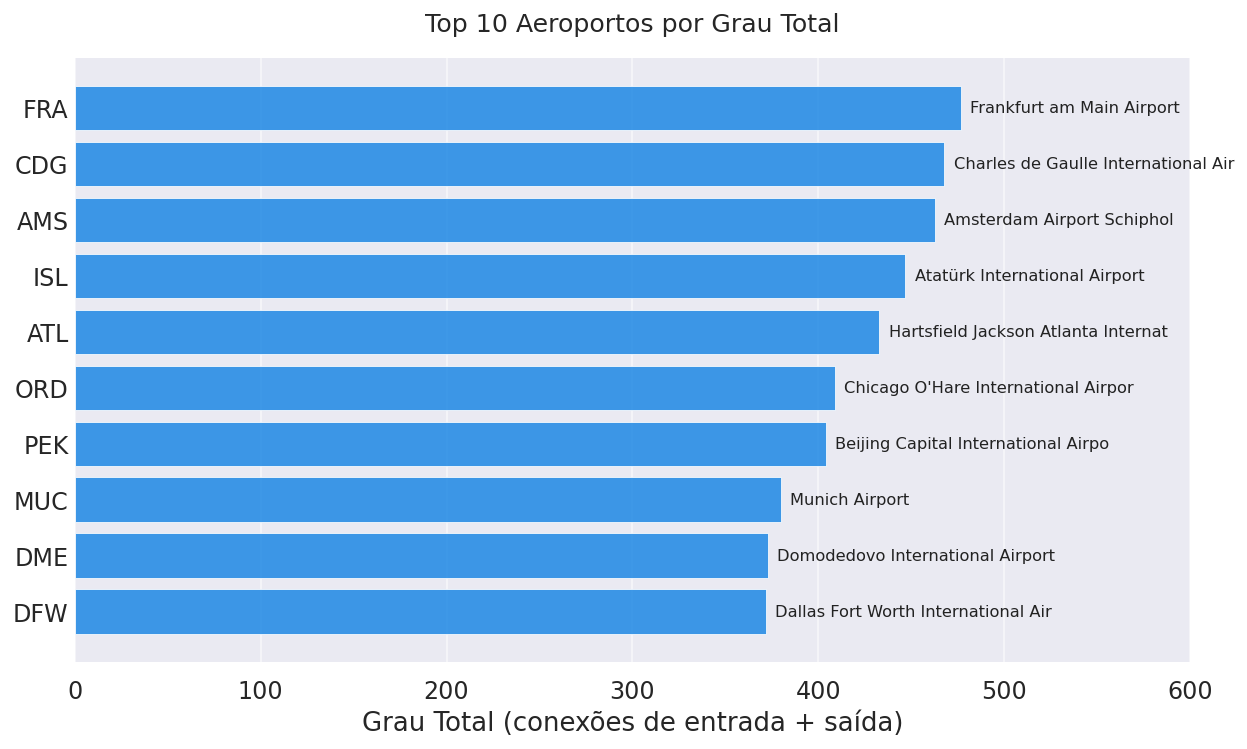

,IATA,Nome,País,Grau Total,In-Degree,Out-Degree
0,FRA,Frankfurt am Main Airport,Germany,477,238,239
1,CDG,Charles de Gaulle International Airport,France,468,232,236
2,AMS,Amsterdam Airport Schiphol,Netherlands,463,231,232
3,ISL,Atatürk International Airport,Turkey,447,225,222
4,ATL,Hartsfield Jackson Atlanta International Airport,United States,433,216,217
5,ORD,Chicago O'Hare International Airport,United States,409,203,206
6,PEK,Beijing Capital International Airport,China,404,202,202
7,MUC,Munich Airport,Germany,380,189,191
8,DME,Domodedovo International Airport,Russia,373,187,186
9,DFW,Dallas Fort Worth International Airport,United States,372,185,187


In [ ]:
degree_df = pd.DataFrame(
    [(n, G.nodes[n]["name"], G.nodes[n]["country"], G.degree(n),
      G.in_degree(n), G.out_degree(n))
     for n in G.nodes],
    columns=["IATA", "Nome", "País", "Grau Total", "In-Degree", "Out-Degree"]
).sort_values("Grau Total", ascending=False).head(10).reset_index(drop=True)

with sns.axes_style("dark"):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    bars = ax.barh(
        degree_df["IATA"][::-1], 
        degree_df["Grau Total"][::-1], 
        color="#1E88E5", 
        alpha=0.85, 
        edgecolor="white", 
        linewidth=0.5
    )
    
    ax.set_xlabel("Grau Total (conexões de entrada + saída)")
    ax.set_title("Top 10 Aeroportos por Grau Total", fontsize=14, pad=15)
    
    ax.set_xlim(0, 600)
    for bar, name in zip(bars, degree_df["Nome"][::-1]):
        ax.text(
            bar.get_width() + 5, 
            bar.get_y() + bar.get_height()/2,
            name[:35], 
            va="center", 
            fontsize=9,
            color="#222222",
            fontweight='medium'
        )
    ax.grid(True, axis="x", linestyle="-", linewidth=1.1, alpha=0.5)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Remove os ticks do eixo Y
    ax.tick_params(axis='y', length=0)
    plt.tight_layout()
    fig.savefig(utils.OUTPUT_DIR / "top_10_aeroportos_grau.png")
    plt.show()
degree_df

### Análise de Centralidades

In [32]:
dc = nx.degree_centrality(G)
bc = nx.betweenness_centrality(G, weight="distance_km")
try:
    ec = nx.eigenvector_centrality(G, max_iter=1000, weight="traffic_estimate")
except Exception:
    ec = nx.eigenvector_centrality_numpy(G, weight="traffic_estimate")

centrality_df = pd.DataFrame({
    "IATA": list(dc.keys()),
    "Nome": [G.nodes[n]["name"] for n in dc],
    "País": [G.nodes[n]["country"] for n in dc],
    "Grau": [G.degree(n) for n in dc],
    "DC": list(dc.values()),
    "BC": list(bc.values()),
    "EC": list(ec.values()),
})

centrality_df.to_csv(utils.OUTPUT_DIR / "centralidades.csv", index=False)
print("Centralidades calculadas e salvas em output/centralidades.csv")

Centralidades calculadas e salvas em output/centralidades.csv


### Top 10 por Cada Centralidade

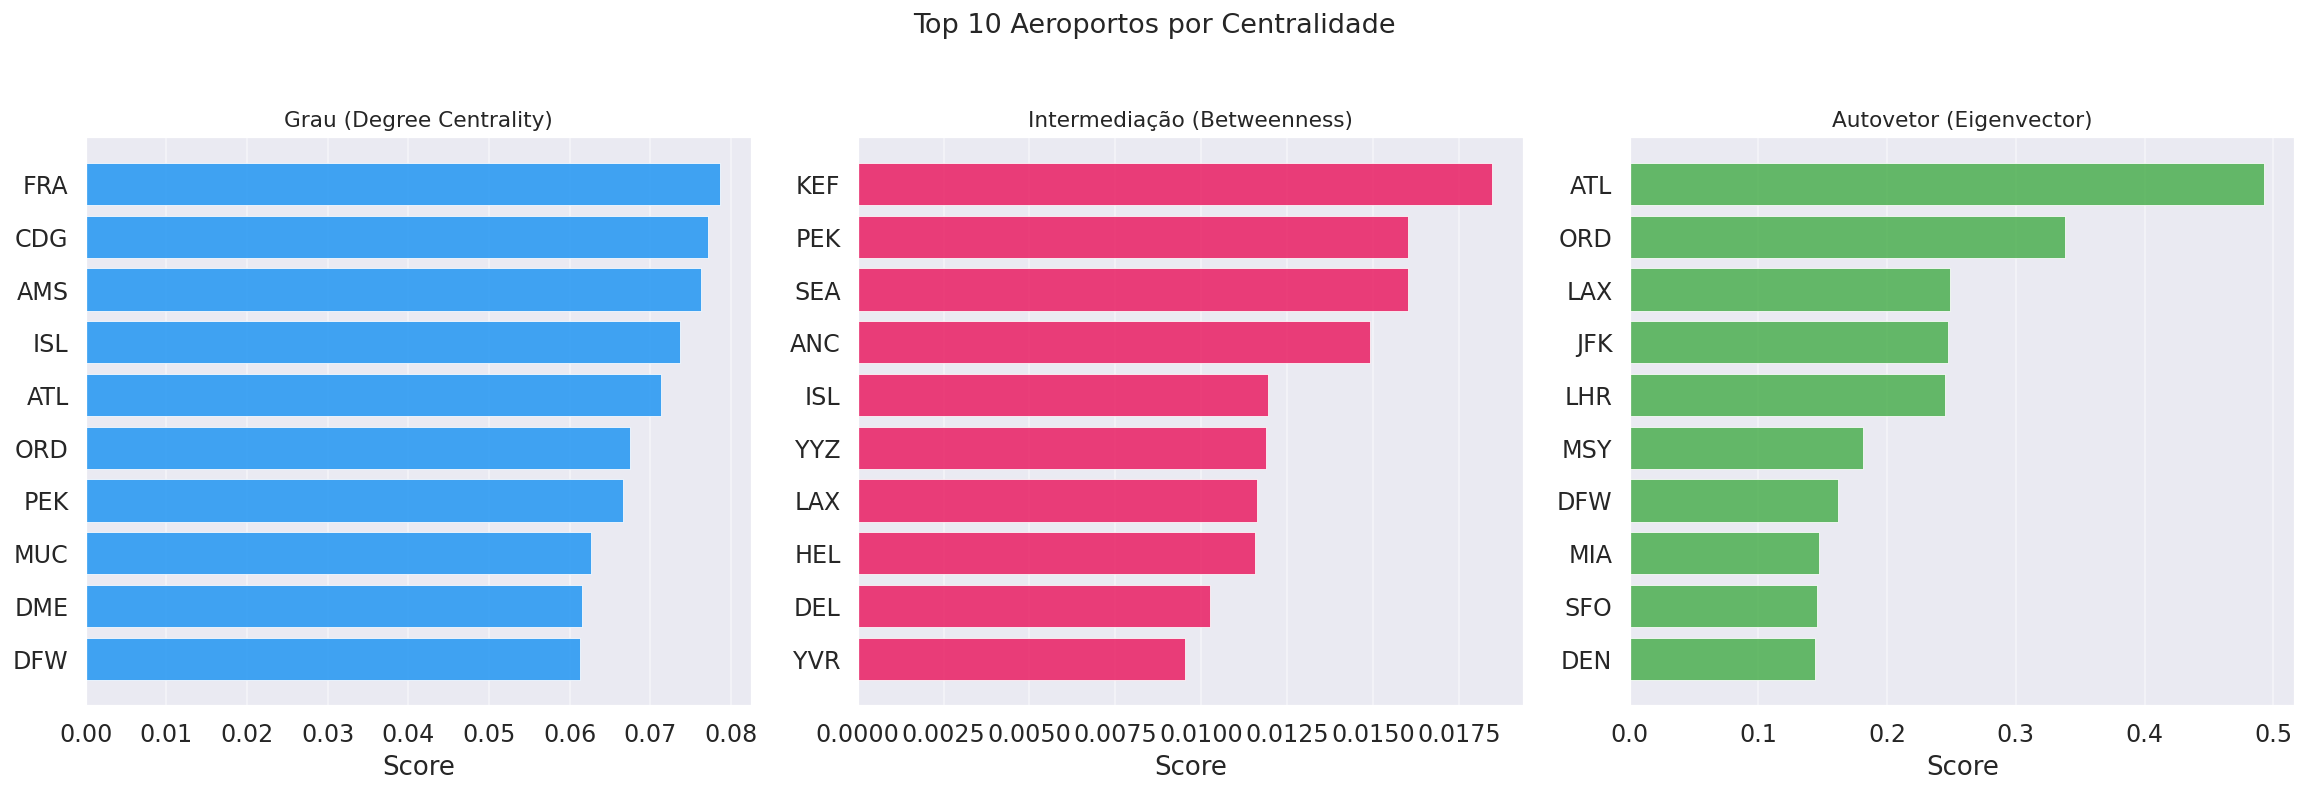

In [37]:
import seaborn as sns

with sns.axes_style("dark"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    configs = [
        ("DC", "Grau (Degree Centrality)", "#2196F3"),
        ("BC", "Intermediação (Betweenness)", "#E91E63"),
        ("EC", "Autovetor (Eigenvector)", "#4CAF50"),
    ]

    for ax, (col, title, color) in zip(axes, configs):
        top = centrality_df.nlargest(10, col)[["IATA", col]].sort_values(col)
        ax.barh(top["IATA"], top[col], color=color, alpha=0.85, edgecolor="white", linewidth=0.5)
        ax.set_title(title, fontsize=12)
        ax.set_xlabel("Score")
        
        ax.grid(True, axis="x", linestyle="-", linewidth=1.1, alpha=0.4)

    plt.suptitle("Top 10 Aeroportos por Centralidade", fontsize=15, y=1.02)
    plt.tight_layout()
    fig.savefig(utils.OUTPUT_DIR / "centralidades_comparativo.png", bbox_inches='tight')
    plt.show()


### Tabela Comparativa – Top 15 Aeroportos

In [35]:
for col in ["DC", "BC", "EC"]:
    centrality_df[f"rank_{col}"] = centrality_df[col].rank(ascending=False)

centrality_df["rank_medio"] = (centrality_df[["rank_DC", "rank_BC", "rank_EC"]].mean(axis=1))

top15 = centrality_df.nsmallest(15, "rank_medio")[
    ["IATA", "Nome", "País", "Grau", "DC", "BC", "EC"]
].reset_index(drop=True)

top15.index += 1
top15.style.background_gradient(subset=["DC", "BC", "EC"], cmap="Blues")

,IATA,Nome,País,Grau,DC,BC,EC
1,ORD,Chicago O'Hare International Airport,United States,409,0.067425,0.009030,0.338179
2,LAX,Los Angeles International Airport,United States,295,0.048632,0.011616,0.248715
3,ATL,Hartsfield Jackson Atlanta International Airport,United States,433,0.071381,0.006291,0.492538
4,LHR,London Heathrow Airport,United Kingdom,338,0.055720,0.007343,0.245152
5,DEN,Denver International Airport,United States,335,0.055226,0.008924,0.143947
6,YYZ,Lester B. Pearson International Airport,Canada,291,0.047972,0.011887,0.106679
7,PEK,Beijing Capital International Airport,China,404,0.066601,0.016024,0.056646
8,JFK,John F Kennedy International Airport,United States,322,0.053083,0.006058,0.247403
9,DFW,Dallas Fort Worth International Airport,United States,372,0.061325,0.005660,0.162060
10,IAH,George Bush Intercontinental Houston Airport,United States,337,0.055556,0.006199,0.087313


### Distribuição de Tráfego nas Arestas

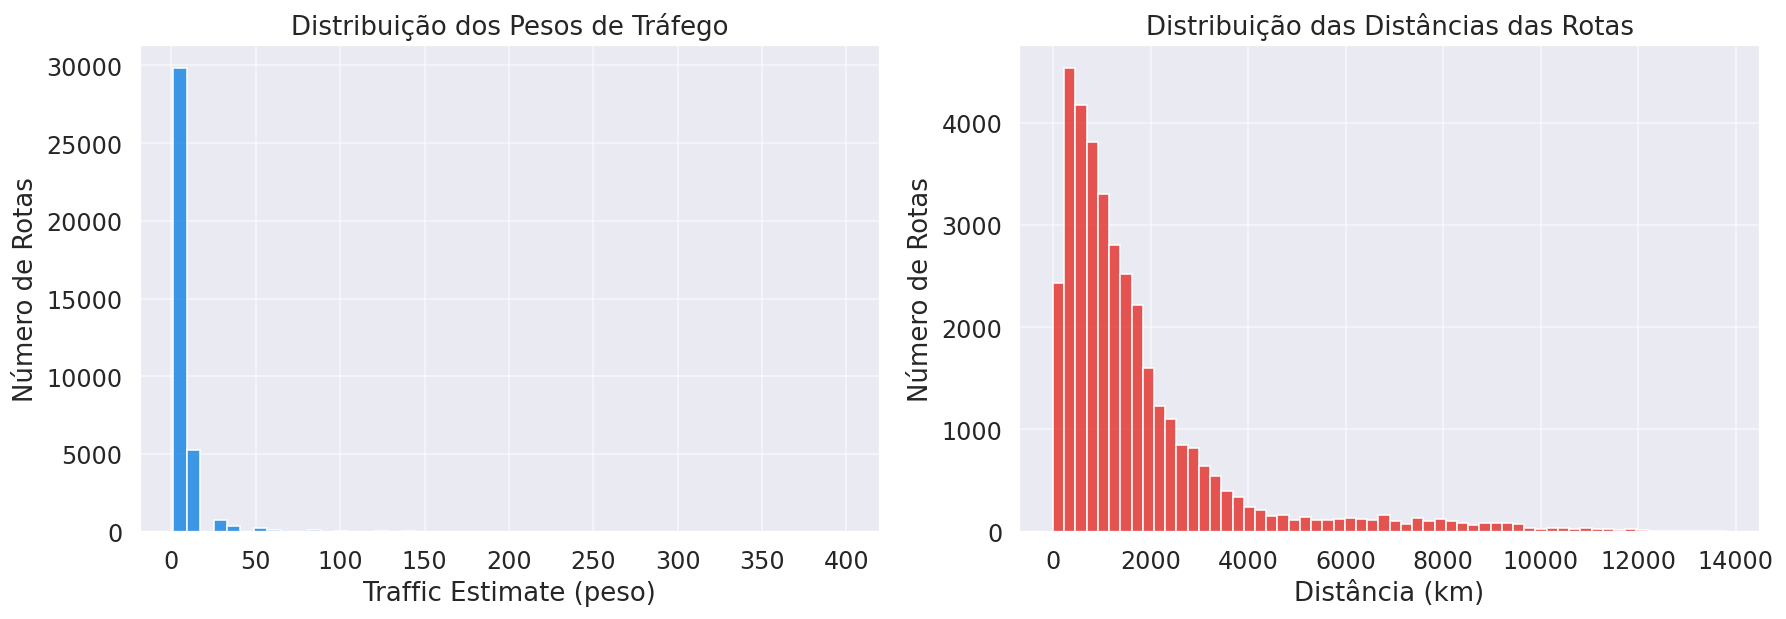

Distância média das rotas: 1758 km
Distância máxima:          13808 km
Traffic estimate médio:    4.93


In [36]:
traffic_vals = [d["traffic_estimate"] for _, _, d in G.edges(data=True)]
dist_vals = [d["distance_km"] for _, _, d in G.edges(data=True)]
with sns.axes_style("dark"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    # --- Histograma de Tráfego (Material Blue 600) ---
    axes[0].hist(
        traffic_vals, bins=50, 
        color="#1E88E5", 
        edgecolor="white", 
        alpha=0.85
    )
    axes[0].set_xlabel("Traffic Estimate (peso)")
    axes[0].set_ylabel("Número de Rotas")
    axes[0].set_title("Distribuição dos Pesos de Tráfego")
    
    axes[0].grid(True, axis="both", linestyle="-", linewidth=1.1, alpha=0.5)
    axes[1].hist(
        dist_vals, bins=60, 
        color="#E53935", 
        edgecolor="white", 
        alpha=0.85
    )
    axes[1].set_xlabel("Distância (km)")
    axes[1].set_ylabel("Número de Rotas")
    axes[1].set_title("Distribuição das Distâncias das Rotas")
    
    axes[1].grid(True, axis="both", linestyle="-", linewidth=1.1, alpha=0.5)
    plt.tight_layout()
    fig.savefig(utils.OUTPUT_DIR / "distribuicao_pesos_arestas.png")
    plt.show()
print(f"Distância média das rotas: {np.mean(dist_vals):.0f} km")
print(f"Distância máxima:          {np.max(dist_vals):.0f} km")
print(f"Traffic estimate médio:    {np.mean(traffic_vals):.2f}")